In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)
SRC_DIR = PROJECT_ROOT 
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

c:\Users\aless\OneDrive\unimi_projects\data_shapley


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import  load_wine
from src.utils import (
    set_seed, make_synthetic_dataset,
    plot_shapley_distribution, plot_removal_curves,
    plot_noise_comparison_curves, plot_shapley_quantiles_by_noise,
    plot_noise_detection_bar,
)
from src.experiment import run_all_noise_levels

set_seed(42)
np.set_printoptions(precision=4, suppress=True)
RESULTS = Path("../results"); 
RESULTS.mkdir(exist_ok=True)
FIGS = RESULTS / "figures"; 
FIGS.mkdir(exist_ok=True)
NOISE_LEVELS = {"no_noise": 0.0, "low": 0.05, "medium": 0.15, "high": 0.30}


Parametri e dataset di input

In [3]:
CANDIDATE_K   = [1, 3, 5, 7, 9,12,14]
FRACTIONS     = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.7]
N_PERMUTATIONS = 100
N_RANDOM_REPEATS = 20
COMPARE_FRACTION = 0.2

wine = load_wine()
X_syn, y_syn = make_synthetic_dataset(n_samples=200, n_features=6, noise_level=0.0, seed=42)

datasets = {
    "wine":    (wine.data, wine.target),
    "synthetic": (X_syn, y_syn),
}
for name, (X, y) in datasets.items():
    print(f"{name:10s} — {X.shape[0]} campioni, {X.shape[1]} feature, "
          f"{len(np.unique(y))} classi")


wine       — 178 campioni, 13 feature, 3 classi
synthetic  — 200 campioni, 6 feature, 2 classi


esegui esperimenti per ogni dataset e configurazione

In [4]:
all_results = {}
for name, (X, y) in datasets.items():
    print(f"\n{'='*55}\nDATASET: {name}\n{'='*55}")
    all_results[name] = run_all_noise_levels(
        X, y, candidate_k=CANDIDATE_K, fractions=FRACTIONS,
        n_permutations=N_PERMUTATIONS, n_random_repeats=N_RANDOM_REPEATS, seed=42,noise_levels=NOISE_LEVELS
    )
    for level in NOISE_LEVELS:
        res = all_results[name][level]
        print(f"  [{level:6s}] k={res['best_k']}, CV={res['cv_score']:.3f}, "
              f"baseline={res['removal']['acc_baseline'][0]:.3f}", end="")
        if res["detection"]:
            d = res["detection"]
            print(f", noise@bottom20={d['n_noise_in_bottom20']}/{d['n_noise']}")
        else:
            print()
 


DATASET: wine


c:\Users\aless\OneDrive\unimi_projects\data_shapley\src\shapley_score.py:24: RuntimeWarning: _score_subset: uso k=14 come vicini > dispo.=1, usando quindi==> k_eff=1
  warnings.warn(
c:\Users\aless\OneDrive\unimi_projects\data_shapley\src\shapley_score.py:24: RuntimeWarning: _score_subset: uso k=14 come vicini > dispo.=2, usando quindi==> k_eff=2
  warnings.warn(
c:\Users\aless\OneDrive\unimi_projects\data_shapley\src\shapley_score.py:24: RuntimeWarning: _score_subset: uso k=14 come vicini > dispo.=3, usando quindi==> k_eff=3
  warnings.warn(
c:\Users\aless\OneDrive\unimi_projects\data_shapley\src\shapley_score.py:24: RuntimeWarning: _score_subset: uso k=14 come vicini > dispo.=4, usando quindi==> k_eff=4
  warnings.warn(
c:\Users\aless\OneDrive\unimi_projects\data_shapley\src\shapley_score.py:24: RuntimeWarning: _score_subset: uso k=14 come vicini > dispo.=5, usando quindi==> k_eff=5
  warnings.warn(
c:\Users\aless\OneDrive\unimi_projects\data_shapley\src\shapley_score.py:24: RuntimeW

  [no_noise] k=1, CV=0.725, baseline=0.706
  [low   ] k=14, CV=0.678, baseline=0.765, noise@bottom20=3/5
  [medium] k=9, CV=0.658, baseline=0.765, noise@bottom20=3/16
  [high  ] k=9, CV=0.529, baseline=0.706, noise@bottom20=14/32

DATASET: synthetic
  [no_noise] k=14, CV=0.885, baseline=0.769
  [low   ] k=14, CV=0.885, baseline=0.769, noise@bottom20=4/6
  [medium] k=14, CV=0.727, baseline=0.795, noise@bottom20=9/18
  [high  ] k=9, CV=0.704, baseline=0.718, noise@bottom20=19/36


distribuzioni e curve per dataset (nbf : salvati prima)

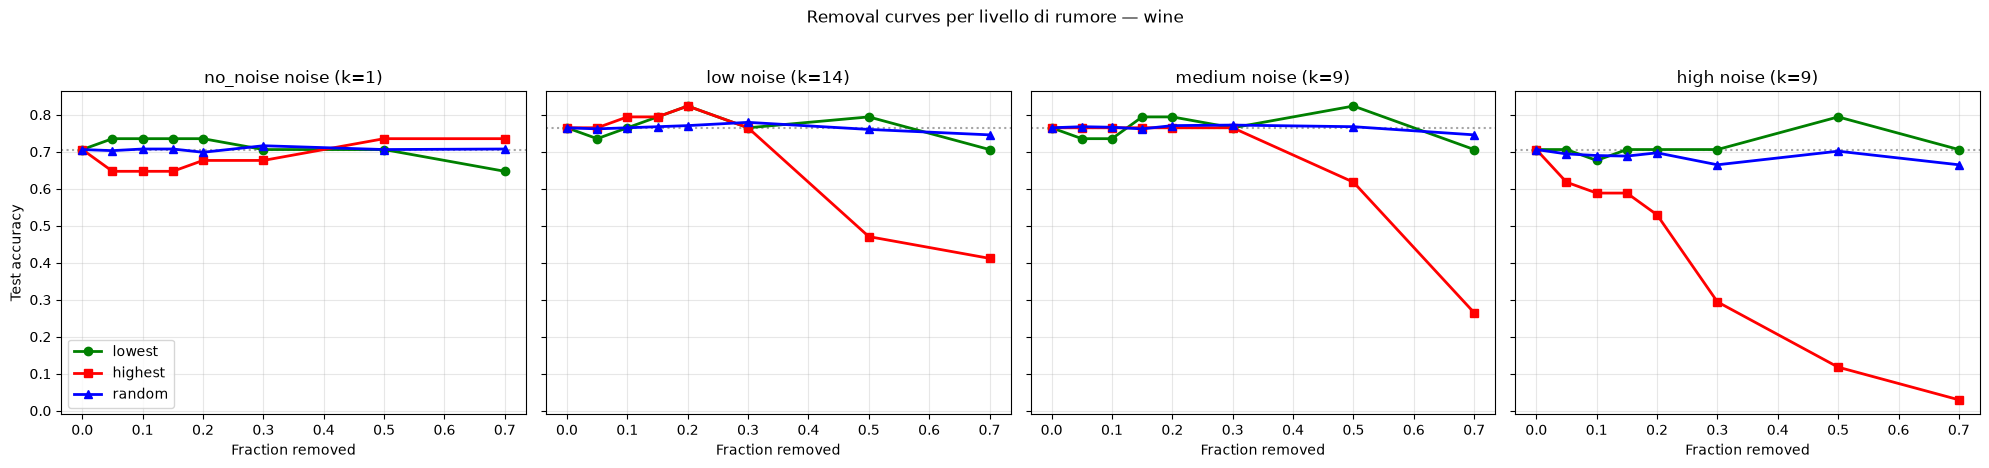

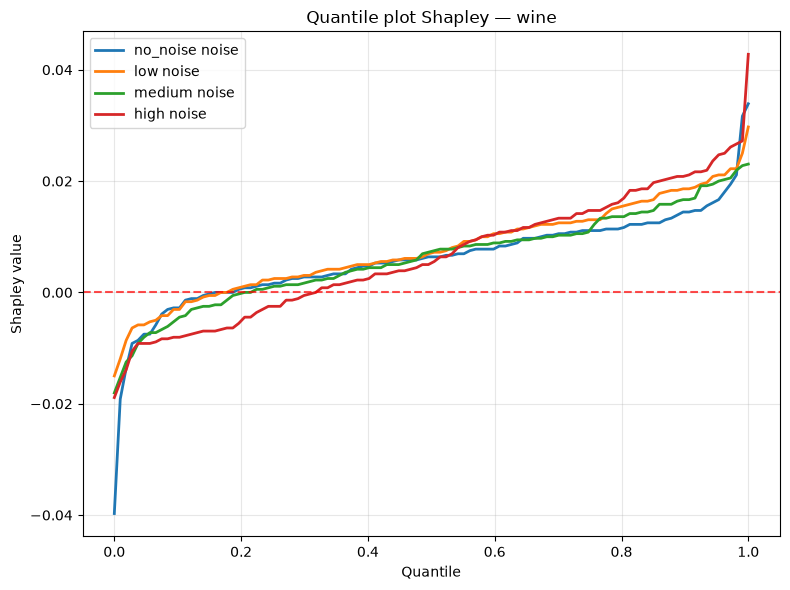

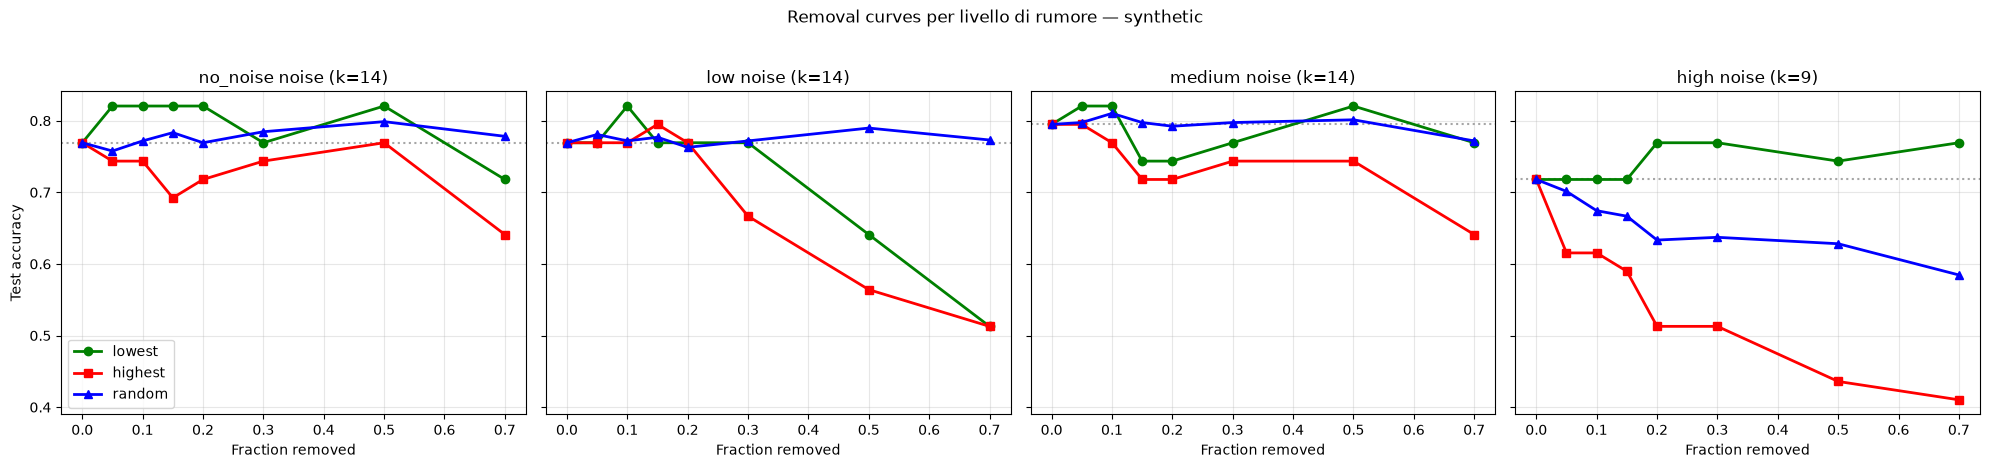

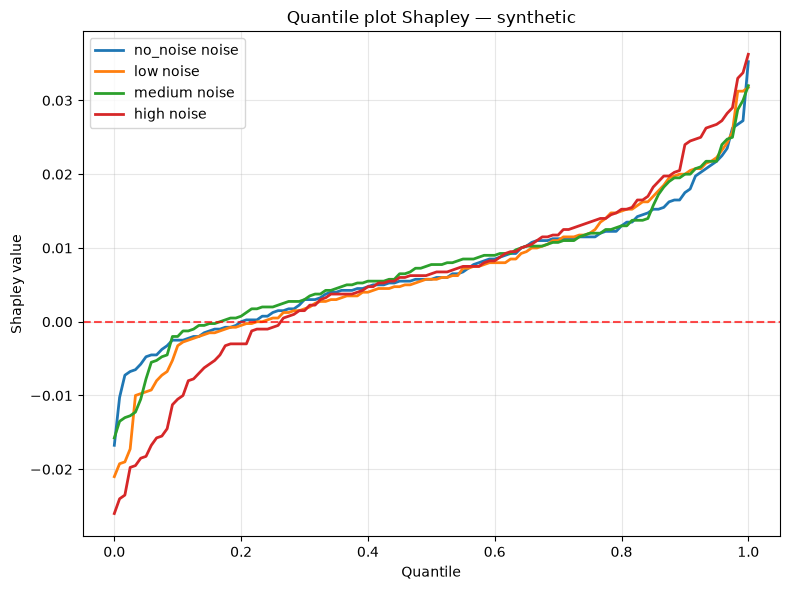

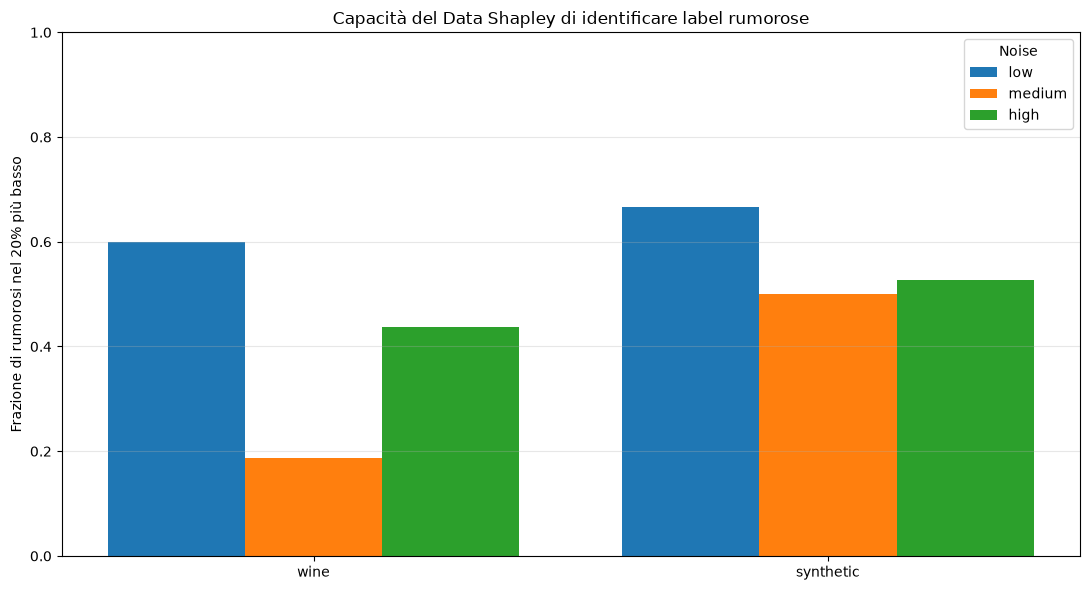

In [5]:
for name in datasets:
    for level in NOISE_LEVELS:
        res = all_results[name][level]
        """
        plot_shapley_distribution(
            res["shapley_values"], title=f"{name} — {level}",
            save_path=FIGS / f"shapley_dist_{name}_{level}.png",
        )
        plot_removal_curves(
            res["removal"], title=f"Removal — {name} ({level} noise)",
            save_path=FIGS / f"removal_{name}_{level}.png",
        )
        """
    plot_noise_comparison_curves(all_results[name],  ds_name=name, levels=list(NOISE_LEVELS.keys()))
    plot_shapley_quantiles_by_noise(
    all_results,
    ds_name=name,
    levels=list(NOISE_LEVELS.keys()),
    save_path=None)
plot_noise_detection_bar(
    all_results, save_path=None, 
    levels = [ l for l in NOISE_LEVELS if l!='no_noise']
)

